# Ensembl VEP Annotations









In [8]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True


import src.utils as utils  
import src.ensemblVEP as ev
import src.onekg as og
import src.haplosaurus as hs

import matplotlib.pyplot as plt
import seaborn as sns
import pooch
from tqdm import tqdm
import polars as pl
import glob 
import pandas as pd
import numpy as np


utils.set_rcparams_nature()
pd.set_option('display.max_columns', None)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Import VEP results

### ESM

In [2]:
# Focus on one model for the main plots
model_name = "esm2_t33_650M_UR50D"

force = False
tmp_vep_path = os.path.expanduser("~/projects/VEP_protein/results/data/vep_df_esm2_t33_650M_UR50D.parquet")
if os.path.exists(tmp_vep_path) and not force:
    print(f"Loading {tmp_vep_path}")
    vep_df = pd.read_parquet(tmp_vep_path)
# "Location" is already in the dataframe 
# Set cached annotation file path
cached_file = os.path.join(pooch.os_cache("pooch"), "cv_annot_ProteinGym_missense.parquet")
 
vep_df = utils.add_variant_name(vep_df,  
                                      chrom_col='#CHROM',
                                    start_col='POS',
                                    end_col=None,
                                    ref_col='REF',
                                    alt_col='ALT',
                                    alias='site', 
                                    force=True
                                    )
 
vep_df.head() 

Loading /home/schilder/projects/VEP_protein/results/data/vep_df_esm2_t33_650M_UR50D.parquet


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,site,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig
0,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,L1045F,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-3.635069,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,chr7:150947347-150947348_G_A,7,150947347,67473,G,A,.,PASS,67473,7:150947347,A,3757,NM_000238.4,Transcript,missense_variant,3541,3133,1045,L/F,Ctc/Ttc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_000238.4:c.3133C>T,NP_000229.1:p.Leu1045Phe,-,NaN,0.00000,78369,"MedGen:CN230736|EFO:EFO_0004269,Human_Phenotyp...",Cardiovascular_phenotype|Cardiac_arrhythmia|Co...,NC_000007.14:g.150947347G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,SO:0001583|missense_variant,1,199473025,NaN,ClinGen:CA008015,None,None,None,NaN,NaN,-6.731237,-0.021689,6,benign
1,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,D1003Y,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-1.670645,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,chr7:150947473-150947474_C_A,7,150947473,200516,C,A,.,PASS,200516,7:150947473,A,3757,NM_000238.4,Transcript,missense_variant,3415,3007,1003,D/Y,Gac/Tac,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.3007G>T,NP_000229.1:p.Asp1003Tyr,-,NaN,NaN,197155,MedGen:CN517202,not_provided,NC_000007.14:g.150947473C>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,794728402,NaN,ClinGen:CA007791,None,None,None,NaN,NaN,-2.509515,-0.039753,6,likely_path
2,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,N996I,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-4.619007,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,chr7:150947493-150947494_T_A,7,150947493,67458,T,A,.,PASS,67458,7:150947493,A,3757,NM_000238.4,Transcript,missense_variant,3395,2987,996,N/I,aAc/aTc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000238.4:c.2987A>T,NP_000229.1:p.Asn996Ile,-,NaN,NaN,78354,"MONDO:MONDO:0019171,MedGen:C1141890,OMIM:PS192...",Congenital_long_QT_syndrome|not_provided|Long_...,NC_000007.14:g.150947493T>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,199473018,NaN,ClinGen:CA007728|UniProtKB:Q12809#VAR_068285,None,None,None,NaN,NaN,-5.869637,-0.057342,6,likely_path
3,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,E978K,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-0.514701,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,chr7:150947639-150947640_C_T,7,150947639,67453,C,T,.,PASS,67453,7:150947639,T,3757,NM_000238.4,Transcript,missense_variant,3340,2932,978,E/K,Gag/Aag,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.2932G>A,NP_000229.1:p.Glu978Lys,-,0.00008,0.00039,78349,"EFO:EFO_0004269,Human_Phenotype_Ontology:HP:00...",Cardiac_arrhythmia|Cardiovascular_phenotype|no...,NC_000007.14

### SpliceAI

In [ ]:
model_name = "SpliceAI"

spliceai_df_path = "../data/1000_Genomes_on_GRCh38/SpliceAI/spliceai_clinvar_merged.parquet"
vep_df = pd.read_parquet(spliceai_df_path) 

# Set cached annotation file path
cached_file = os.path.join(pooch.os_cache("pooch"), "cv_annot_SpliceVarDB_splicing.parquet")
 
vep_df = utils.add_variant_name(vep_df,  
                                    chrom_col='chromosome',
                                    start_col='position',
                                    end_col=None,
                                    ref_col='ref_allele',
                                    alt_col='alt_allele',
                                    alias='site', 
                                    force=True
                                    )

Column site already exists in dataframe, skipping


### All others (Flashzoi)

In [95]:
model_name = "Flashzoi"

variant_set="clinvar_utr_snv"
xr_mfds_dir=os.path.join(
    os.path.expanduser('~'),
    "projects/data/1000_Genomes_on_GRCh38",
    variant_set
)

pq_file = os.path.join(xr_mfds_dir, "vep_df.parquet")  
vep_df = pd.read_parquet(pq_file)

vep_df["VEP"] = vep_df["flashzoi"]

# Set cached annotation file path
cached_file = os.path.join(pooch.os_cache("pooch"), "cv_annot_ClinVar_UTR.parquet")

# vep_df["Location"] = vep_df["chrom"].astype(str) + ":" + vep_df["chromStart"].astype(str) + "-" + vep_df["chromStart"].astype(str)
vep_df = utils.add_variant_name(vep_df,  
                                    chrom_col='chrom',
                                    start_col='chromStart',
                                    end_col=None,
                                    ref_col='REF',
                                    alt_col='ALT',
                                    alias='site', 
                                    force=True
                                    )

KeyboardInterrupt: 

## Filter and merge annotation files

In [ ]:
cv_annot = ev.filter_annotations(
    df= vep_df,
    df_filters = {"site": "site"}, 
    cache_search = os.path.join(os.path.expanduser("~/projects/data/ensemblVEP"), "clinvarVEP*"),
    cached_file = cached_file,
    force = True
)  
cv_annot.head()

Processing VEP annotation files:   0%|          | 0/25 [00:00<?, ?it/s]

Processing VEP annotation files:   4%|▍         | 1/25 [01:28<35:35, 88.98s/it]

clinvarVEP_chr4.txt.gz (1235, 482)


Processing VEP annotation files:   8%|▊         | 2/25 [04:20<52:39, 137.37s/it]

clinvarVEP_chr5.txt.gz (1461, 482)


#### Plot EnsemblVEP annotation correlation difference: VEPmean vs. VEPref

In [89]:
# Aggregate VEP scores
if "is_ref" not in vep_df.columns:
    vep_df["is_ref"] = vep_df["sample"] == "REF"
agg_cols = [x for x in ["is_ref","site","spliceogenicity","CLNSIG_simplified","CLNSIG_simple","clinsig"] if x in vep_df.columns]
vep_agg = vep_df.groupby(agg_cols, observed=True).agg({"VEP": "mean"}).reset_index()
if "CLNSIG_simplified" in vep_df.columns:
    vep_agg.rename(columns={"CLNSIG_simplified":"CLNSIG_simple"}, inplace=True)
print("vep_agg.shape:",vep_agg.shape)

# Merge VEP scores with ClinVar annotations
on_cols = ["site"]
rm_cols = [col for col in cv_annot.columns if col not in on_cols and col in vep_agg.columns]
vep_annot = vep_agg.drop(columns=rm_cols).merge(cv_annot.drop_duplicates(subset="site"), on=on_cols, how="inner")
print("vep_annot.shape:",vep_annot.shape)
vep_annot.head() 

vep_agg.shape: (16469, 5)
vep_annot.shape: (6038, 494)


,is_ref,site,spliceogenicity,CLNSIG_simple,VEP,#Uploaded_variation,Location,Allele,Consequence,IMPACT,SYMBOL,Gene,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,REF_ALLELE,UPLOADED_ALLELE,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,CANONICAL,MANE,MANE_SELECT,MANE_PLUS_CLINICAL,TSL,APPRIS,CCDS,ENSP,SWISSPROT,TREMBL,UNIPARC,UNIPROT_ISOFORM,SOURCE,SIFT,PolyPhen,miRNA,HGVS_OFFSET,AF,AFR_AF,AMR_AF,EAS_AF,EUR_AF,SAS_AF,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_MID_AF,gnomADe_NFE_AF,gnomADe_REMAINING_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_REMAINING_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,PUBMED,VAR_SYNONYMS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,OpenTargets_geneId,OpenTargets_l2g,CADD_PHRED,CADD_RAW,Mastermind_MMID3,Geno2MP_HPO_count,Geno2MP_URL,ada_score,rf_score,BLOSUM62,Enformer_SAD,Enformer_SAR,NMD,EVE_CLASS,EVE_SCORE,5UTR_annotation,5UTR_consequence,Existing_InFrame_oORFs,Existing_OutOfFrame_oORFs,Existing_uORFs,PHENOTYPES,IntAct_ap_ac,IntAct_feature_ac,IntAct_feature_annotation,IntAct_feature_short_label,IntAct_feature_type,IntAct_interaction_ac,IntAct_interaction_participants,IntAct_pmid,MaveDB_nt,MaveDB_pro,MaveDB_score,MaveDB_urn,pHaplo,pTriplo,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,RiboseqORFs_CDS_position,RiboseqORFs_amino_acids,RiboseqORFs_cDNA_position,RiboseqORFs_codons,RiboseqORFs_consequences,RiboseqORFs_id,RiboseqORFs_impact,RiboseqORFs_protein_position,RiboseqORFs_publications,ClinPred,LOEUF,GO,mutfunc_exp,mutfunc_int,mutfunc_mod,mutfunc_motif,1000Gp3_AC,1000Gp3_AF,1000Gp3_AFR_AC,1000Gp3_AFR_AF,1000Gp3_AMR_AC,1000Gp3_AMR_AF,1000Gp3_EAS_AC,1000Gp3_EAS_AF,1000Gp3_EUR_AC,1000Gp3_EUR_AF,1000Gp3_SAS_AC,1000Gp3_SAS_AF,ALFA_African_AC,ALFA_African_AF,ALFA_African_AN,ALFA_African_American_AC,ALFA_African_American_AF,ALFA_African_American_AN,ALFA_African_Others_AC,ALFA_African_Others_AF,ALFA_African_Others_AN,ALFA_Asian_AC,ALFA_Asian_AF,ALFA_Asian_AN,ALFA_East_Asian_AC,ALFA_East_Asian_AF,ALFA_East_Asian_AN,ALFA_European_AC,ALFA_European_AF,ALFA_European_AN,ALFA_Latin_American_1_AC,ALFA_Latin_American_1_AF,ALFA_Latin_American_1_AN,ALFA_Latin_American_2_AC,ALFA_Latin_American_2_AF,ALFA_Latin_American_2_AN,ALFA_Other_AC,ALFA_Other_AF,ALFA_Other_AN,ALFA_Other_Asian_AC,ALFA_Other_Asian_AF,ALFA_Other_Asian_AN,ALFA_South_Asian_AC,ALFA_South_Asian_AF,ALFA_South_Asian_AN,ALFA_Total_AC,ALFA_Total_AF,ALFA_Total_AN,Aloft_Confidence,Aloft_Fraction_transcripts_affected,Aloft_pred,Aloft_prob_Dominant,Aloft_prob_Recessive,Aloft_prob_Tolerant,AlphaMissense_pred,AlphaMissense_rankscore,AlphaMissense_score,AltaiNeandertal,BayesDel_addAF_pred,BayesDel_addAF_rankscore,BayesDel_addAF_score,BayesDel_noAF_pred,BayesDel_noAF_rankscore,BayesDel_noAF_score,ChagyrskayaNeandertal,DANN_rankscore,DANN_score,DEOGEN2_pred,DEOGEN2_rankscore,DEOGEN2_score,Denisova,ESM1b_pred,ESM1b_rankscore,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,Eigen-PC-raw_coding_rankscore,Eigen-phred_coding,Eigen-raw_coding,Eigen-raw_coding_rankscore,Ensembl_geneid,Ensembl_proteinid,Ensembl_transcriptid,GERP++_NR,GERP++_RS,GERP++_RS_rankscore,GERP_91_mammals,GERP_91_mammals_rankscore,Interpro_domain,LIST-S2_pred,LIST-S2_rankscore,LIST-S2_score,MPC_rankscore,MPC_score,MVP_rankscore,MVP_score,MetaLR_pred,MetaLR_rankscore,MetaLR_score,MetaRNN_pred,MetaRNN_rankscore,MetaRNN_score,MetaSVM_pred,MetaSVM_rankscore,MetaSVM_score,MutFormer_rankscore,MutFormer_score,MutationAssessor_pred,MutationAssessor_rankscore,MutationAssessor_score,MutationTaster_converted_rankscore,MutationTaster_model,MutationTaster_pred,

Compute correlations between VEP scores and EnsemblVEP annotations. 

Then compare the difference in VEP scores between reference-derived VEPs and averaged non-reference-derived (personalized) VEPs.

In [90]:
r2_df = ev.run_correlation_analysis(vep_annot, 
                                    ANNOT_COLS=ev.ANNOT_COLS, 
                                    # ref_vs_all=True,
                                    # transform="exp2", 
                                    # method="pearson"
                                    )

Calculating Spearman r:   0%|          | 0/133 [00:00<?, ?it/s]

Calculating Spearman r:   8%|▊         | 10/133 [00:00<00:04, 28.31it/s]/home/schilder/projects/VEP_protein/src/ensemblVEP.py:439: UserWarning: Error converting VEP and MPC_score to float
  warnings.warn(f"Error converting {vep_col} and {col} to float")
/home/schilder/projects/VEP_protein/src/ensemblVEP.py:439: UserWarning: Error converting VEP and MetaRNN_score to float
  warnings.warn(f"Error converting {vep_col} and {col} to float")
Calculating Spearman r:  21%|██        | 28/133 [00:01<00:04, 21.09it/s]/home/schilder/projects/VEP_protein/src/ensemblVEP.py:439: UserWarning: Error converting VEP and gMVP_score to float
  warnings.warn(f"Error converting {vep_col} and {col} to float")
Calculating Spearman r:  23%|██▎       | 31/133 [00:01<00:04, 23.00it/s]/home/schilder/projects/VEP_protein/src/ensemblVEP.py:439: UserWarning: Error converting VEP and PROVEAN_pred to float
  warnings.warn(f"Error converting {vep_col} and {col} to float")
/home/schilder/projects/VEP_protein/src/ensemblV


R2 Results Summary:
                            annotation     ref_r  nonref_r    r_diff  \
13                   Reliability_index -0.097905 -0.092894  0.005011   
52               MaveDB_score_abs_mean  0.123026  0.127030  0.004004   
2                             ClinPred  0.066781  0.070250  0.003469   
3                 BayesDel_addAF_score  0.109675  0.112906  0.003232   
12  MutationTaster_converted_rankscore  0.120620  0.122551  0.001931   
..                                 ...       ...       ...       ...   
92                      1000Gp3_AFR_AF       NaN       NaN       NaN   
93                      1000Gp3_AMR_AF       NaN       NaN       NaN   
94                      1000Gp3_EAS_AF       NaN       NaN       NaN   
95                      1000Gp3_EUR_AF       NaN       NaN       NaN   
96                      1000Gp3_SAS_AF       NaN       NaN       NaN   

    rabs_diff   r2_diff  ref_n  nonref_n         ref_p      nonref_p  ref_fdr  \
13  -0.005011 -0.000956   1572   

Partial explanation of EnsemblVEP columns:
- https://useast.ensembl.org/info/docs/tools/vep/vep_formats.html#tab

In [91]:
# r2_df.loc[r2_df["ref_p"]<0.05, "ref_r"] = 0
# r2_df.loc[r2_df["nonref_p"]<0.05, "nonref_r"] = 0
# r2_df["r_diff"] = r2_df["nonref_r"] - r2_df["ref_r"]

# r2_df["combined_diff"] = (r2_df["nonref_r"] *(1-r2_df["nonref_p"])) - (r2_df["ref_r"] *(1-r2_df["ref_p"]))
# r2_df["combined_abs_diff"] = (r2_df["nonref_r"].abs() *(1-r2_df["nonref_p"])) - (r2_df["ref_r"].abs() *(1-r2_df["ref_p"]))
# r2_df["combined2_diff"] = (r2_df["nonref_r"] *(1-r2_df["nonref_p"])).pow(2) - (r2_df["ref_r"] *(1-r2_df["ref_p"])).pow(2) 

In [92]:
r2_df

,annotation,ref_r,nonref_r,r_diff,rabs_diff,r2_diff,ref_n,nonref_n,ref_p,nonref_p,ref_fdr,nonref_fdr,combined_diff,combined_abs_diff,combined2_diff
0,CADD_PHRED,0.282073,0.283467,0.001394,0.001394,0.000788,3019,3019,2.475428e-56,6.763102e-57,NaN,NaN,0.001394,0.001394,0.000788
1,CADD_RAW,0.282395,0.283785,0.001390,0.001390,0.000787,3019,3019,1.835997e-56,5.025250e-57,NaN,NaN,0.001390,0.001390,0.000787
2,ClinPred,0.066781,0.070250,0.003469,0.003469,0.000475,1580,1580,7.922407e-03,5.211921e-03,NaN,NaN,0.003632,0.003632,0.000494
3,BayesDel_addAF_score,0.109675,0.112906,0.003232,0.003232,0.000719,1746,1746,4.361577e-06,2.250010e-06,NaN,NaN,0.003232,0.003232,0.000719
4,BayesDel_noAF_score,0.109930,0.111748,0.001818,0.001818,0.000403,1746,1746,4.142447e-06,2.858362e-06,NaN,NaN,0.001819,0.001819,0.000403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,pHaplo,-0.142621,-0.144567,-0.001945,0.001945,0.000559,2940,2940,7.871148e-15,3.360504e-15,NaN,NaN,-0.001945,0.001945,0.000559
112,pTriplo,-0.062867,-0.066604,-0.003737,0.003737,0.000484,2940,2940,6.480520e-04,3.016882e-04,NaN,NaN,-0.003758,0.003758,0.000486
113,bStatistic,-0.021635,-0.020949,0.000686,-0.000686,-0.000029,1725,1725,3.691687e-01,3.845450e-01,NaN,NaN,0.000755,-0.000755,-0.000020
114,bStatistic_converted_rankscore,0.021635,0.020949,-0.000686,-0.000686,-0.000029,1725,1725,3.691687e-01,3.845450e-01,NaN,NaN,-0.000755,-0.000755,-0.000020


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


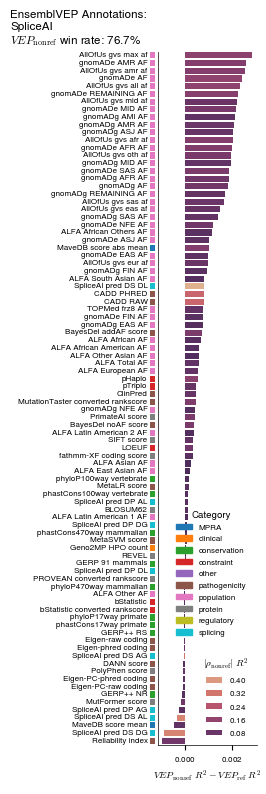

In [93]:

# Organize, sort and group keyword arguments by purpose and convention
plot_correlation_analysis_out = ev.plot_correlation_analysis(
    # Data
    r2_df=r2_df.dropna(axis=1, how='all').dropna(axis=0, how='all'),

    # Axes and variables
    x_var="r2_diff",
    flip_axes=False,
    # yticklabel_rotation=315,

    # Display and category aesthetics
    show_category_column=True,
    category_palette="tab10",
    ticklabel_fontsize='small',
    category_legend_bbox_to_anchor=(0.35, 0.3),
    category_box_linewidth=0,
    category_legend_fontsize='small', 
    legend_fontsize='small',   

    # Labels and titles
    yticklabel_pad= -.5,
    xlabel=r"$VEP_{\text{nonref}}\ R^2 - VEP_{\text{ref}}\ R^2$",
    legend_title= r"$|ρ_{\text{nonref}}|\ R^2$",
    title=f"EnsemblVEP Annotations:\n{model_name}",
    title_x=-1.5,
    ylabel=None,

    # Figure appearance/size
    figsize=(1.4, 9),

    # Optional and less-used arguments (commented)
    # min_n=20,
    # max_p=0.05,
    # min_diff=1e-10,
    # annotations=[x for x in ev.ANNOT_COLS if not x.lower().endswith("af") and "SpliceAI" not in x],
)

plot_correlation_analysis_out['fig'].savefig(
    f"manuscript/fig/vep_correlation_differences_{model_name}.pdf",
    **utils.FIG_SAVE_KWARGS
)


## Correlate VEP with Population Frequencies

In [7]:
haplotypes = hs.get_haplotypes(cache_only=True,
                                tx_ids=vep_df['ENST'].unique()
                                ) 
vep_df = hs.add_haplotype_freqs(vep_df, haplotypes=haplotypes)

Found haplotypes of 47329 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes'


Getting haplotypes:   0%|          | 0/2141 [00:00<?, ?it/s]

Getting haplotype frequencies:   0%|          | 0/2141 [00:00<?, ?it/s]

Using all 3 cohorts.
Using 38 populations
Adding haplotype frequencies per population
Adding top superpopulation
0 samples are missing superpopulation metadata
0 samples are missing superpopulation metadata

Number of variants specific to each population:
specific_population
1000GENOMES:phase_3:LWK    3113
1000GENOMES:phase_3:JPT    2611
1000GENOMES:phase_3:CHB    2528
1000GENOMES:phase_3:TSI    2447
1000GENOMES:phase_3:CHS    2379
1000GENOMES:phase_3:STU    2328
1000GENOMES:phase_3:ITU    2247
1000GENOMES:phase_3:BEB    2225
1000GENOMES:phase_3:KHV    2195
1000GENOMES:phase_3:MSL    2167
1000GENOMES:phase_3:YRI    2132
1000GENOMES:phase_3:ACB    2032
1000GENOMES:phase_3:IBS    2027
1000GENOMES:phase_3:PJL    2008
1000GENOMES:phase_3:CDX    1974
1000GENOMES:phase_3:PEL    1966
1000GENOMES:phase_3:GIH    1935
1000GENOMES:phase_3:ESN    1837
1000GENOMES:phase_3:CEU    1774
1000GENOMES:phase_3:CLM    1696
1000GENOMES:phase_3:PUR    1683
GGVP:GWD                   1512
1000GENOMES:phase_3:

100%|██████████| 9/9 [00:44<00:00,  4.96s/it]


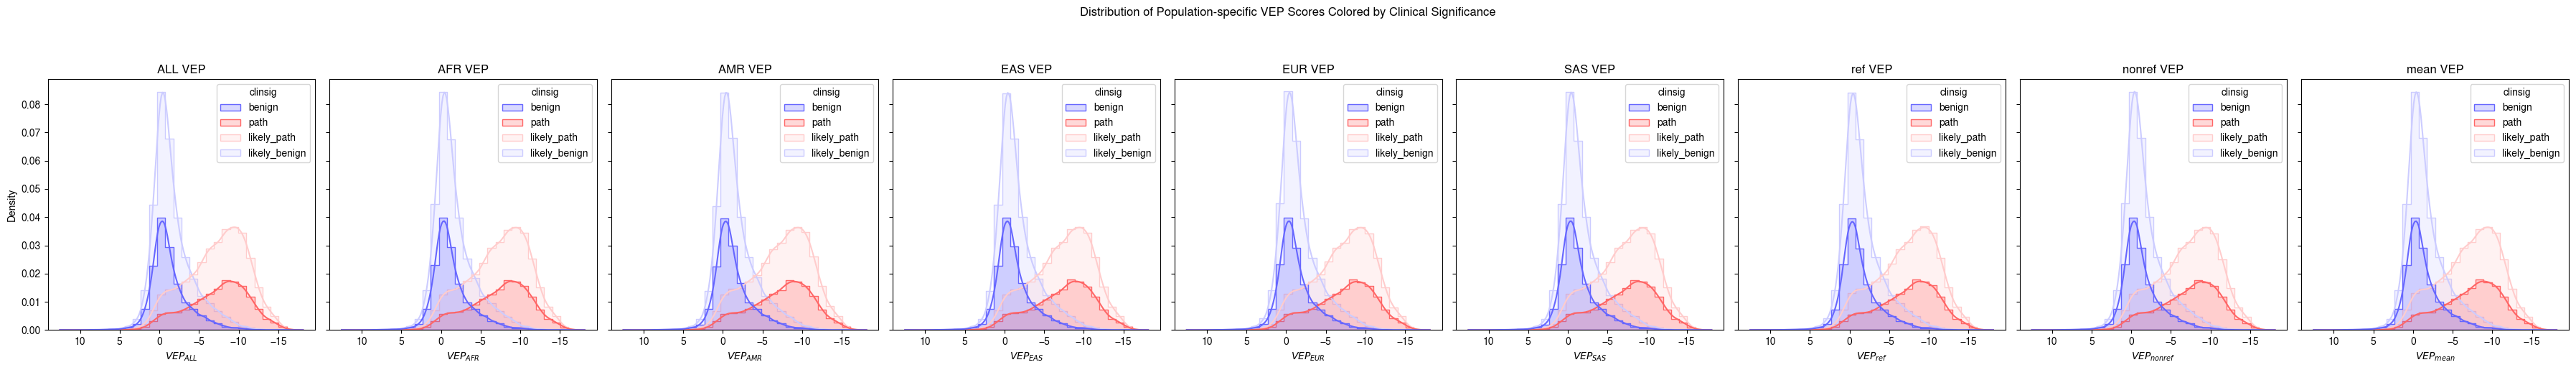

In [8]:
target_pops = ["ALL", "AFR", "AMR", "EAS", "EUR", "SAS", "ref", "nonref", "mean"]
freq_cols = [x for x in vep_df.columns if x.startswith("freq_1000GENOMES") and any(f":{pop}" in x for pop in target_pops)]

import matplotlib.pyplot as plt
import seaborn as sns

# For each selected population, prepare a subplot of pop-specific VEP distribution colored by clinsig
n_pops = len(target_pops)
fig, axes = plt.subplots(1, n_pops, figsize=(4 * n_pops, 5), sharey=True)
dfs = []

for i, pop in tqdm(enumerate(target_pops), total=len(target_pops)):
    vep_pop_col = f"VEP_{pop}"
    ax = axes[i] if n_pops > 1 else axes
    group_cols = ["site", "clinsig"]
    value_col = "VEP"

    # Prepare data for this population
    if pop == "ref":
        # Just subset to reference haplotypes
        vep_subset = vep_df[vep_df["is_ref"] == True].dropna(subset=["VEP", "clinsig"]).copy()
    elif pop == "nonref" or pop == "vep_nonref":
        # Just subset to non-reference haplotypes (inverted compared to ref)
        vep_subset = vep_df[vep_df["is_ref"] == False].dropna(subset=["VEP", "clinsig"]).copy()
    elif pop == "mean":
        # Use all samples with VEP and clinsig for the unweighted mean
        vep_subset = vep_df.dropna(subset=["VEP", "clinsig"]).copy()
    else:
        freq_col = [x for x in freq_cols if x.endswith(f":{pop}")]
        if not freq_col:
            continue
        freq_col = freq_col[0]
        # Calculate population-weighted VEP
        vep_df[vep_pop_col] = vep_df["VEP"] * vep_df[freq_col]
        vep_df.loc[vep_df[freq_col].isna() | (vep_df[freq_col] == 0), vep_pop_col] = pd.NA
        # Use appropriate subset/columns for grouping/plotting
        vep_subset = vep_df.dropna(subset=[vep_pop_col, freq_col, "clinsig"]).copy()

    # Compute mean VEP per (site, clinsig)
    vep_sp = vep_subset.groupby(group_cols).agg({value_col: "mean"}).reset_index()
    vep_sp.rename(columns={value_col: vep_pop_col}, inplace=True)
    dfs.append(vep_sp)
    sns.histplot(
        data=vep_sp,
        x=vep_pop_col,
        hue="clinsig",
        palette=utils.get_clinsig_palette(),
        kde=True,
        bins=30,
        ax=ax,
        element="step",
        stat="density"
    )

    ax.set_title(f"{pop} VEP")
    ax.set_xlabel(ev.to_latex_subscript(vep_pop_col))
    ax.invert_xaxis()
    if i == 0:
        ax.set_ylabel("Density")
    else:
        ax.set_ylabel("")

plt.tight_layout()
plt.suptitle("Distribution of Population-specific VEP Scores Colored by Clinical Significance", y=1.02)
plt.subplots_adjust(top=0.82)
plt.show()


In [9]:
# Iteratively merge population-specific VEP DataFrames on 'site' and 'clinsig'
from functools import reduce
vep_superpop_agg = reduce(
    lambda left, right: pd.merge(left, right, on=["site", "clinsig"], how="outer"),
    dfs
)
vep_superpop_agg

,site,clinsig,VEP_ALL,VEP_AFR,VEP_AMR,VEP_EAS,VEP_EUR,VEP_SAS,VEP_ref,VEP_nonref,VEP_mean
0,chr10:100152307-100152308_T_C,benign,-4.026721,-3.969645,-3.954621,-4.127174,-3.971370,-3.972418,-3.971370,-4.018207,-4.014861
1,chr10:100178156-100178157_A_G,path,-8.671664,-8.677925,-8.674498,-8.678130,-8.679862,-8.668399,-8.692718,-8.652227,-8.655119
2,chr10:100233267-100233268_C_T,benign,-5.574040,-5.543646,-5.711598,-5.527804,-5.743791,-5.671358,-5.577965,-5.403971,-5.408942
3,chr10:100233333-100233334_T_A,benign,-5.879143,-5.871176,-5.881173,-5.889248,-5.875328,-5.895770,-5.934132,-5.703488,-5.710078
4,chr10:100245823-100245824_G_A,benign,-0.593498,-0.603826,-0.500521,-0.623364,-0.561387,-0.557170,-0.579560,-0.570940,-0.571186
...,...,...,...,...,...,...,...,...,...,...,...
56296,chrX:9895083-9895084_A_G,likely_benign,1.873829,1.874107,1.873148,1.872782,1.888443,1.872684,1.876007,1.874046,1.874056
56297,chrX:9895368-9895369_C_T,likely_benign,-1.335880,-1.371402,-1.371169,-1.211345,-1.203473,-1.327614,-1.372123,-1.336506,-1.336685
56298,chrX:9896103-9896104_T_A,benign,0.245993,0.252952,0.253286,0.221118,0.222654,0.244755,0.252731,0.246105,0.246138
56299,chrX:9896403-9896404_C_T,benign,-1.555803,-1.596237,-1.595466,-1.408969,-1.418118,-1.549606,-1.596015,-1.555114,-1.555320


In [ ]:
vep_superpop_agg = ev.compute_vep_superpopulation_aggregates(vep_df)
print(vep_superpop_agg.shape)
vep_superpop_agg.head()

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


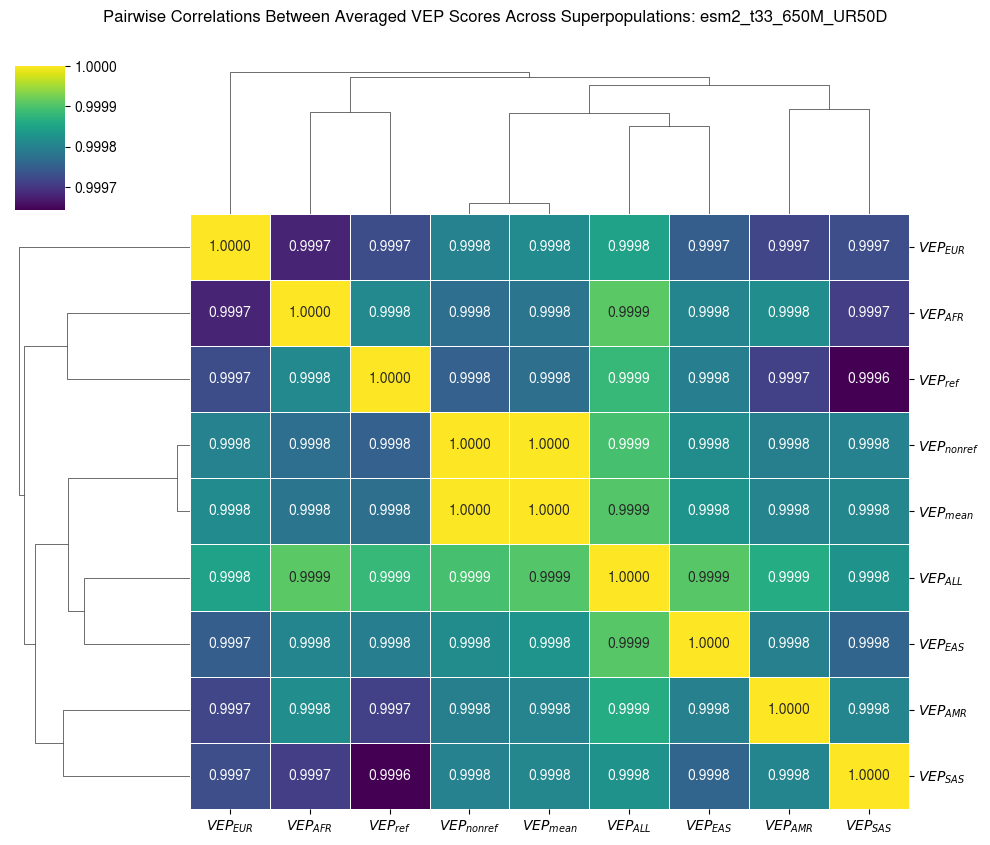

In [11]:
# Select only the columns containing superpopulation VEP means and any other VEP mean columns
vep_cols = [col for col in vep_superpop_agg.columns if col.startswith("VEP_")]

# Compute correlation matrix pairwise, dropping NA pairs for each calculation
vep_corr = vep_superpop_agg[vep_cols].corr(method="spearman", min_periods=1)

# Alternatively, some users may prefer: .corr(method="pearson") with .dropna() per column-pair;
# but recent pandas uses pairwise deletion by default unless interfering groupby/categorical.

# Visualize as clustermap instead of a heatmap
# Remove underscores for display, but keep original data for clustering


vep_corr_display = vep_corr.copy()
vep_corr_display.index = [ev.to_latex_subscript(idx) for idx in vep_corr_display.index]
vep_corr_display.columns = [ev.to_latex_subscript(col) for col in vep_corr_display.columns]

# Show only one triangle of the symmetric correlation matrix

mask = np.triu(np.ones_like(vep_corr, dtype=bool), k=1)  # mask upper triangle
g = sns.clustermap(
    vep_corr,
    annot=True,
    fmt=".4f",
    cmap="viridis",
    linewidths=0.5,
    figsize=(10, 8),
    xticklabels=vep_corr_display.columns,
    yticklabels=vep_corr_display.index,
    # row_cluster=False,
    # mask=mask,
    square=True
)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=0)

plt.suptitle(f"Pairwise Correlations Between Averaged VEP Scores Across Superpopulations: {model_name}", y=1.05)
plt.show()

g.fig.savefig(f"manuscript/fig/vep_superpop_corr_{model_name}.pdf", **utils.FIG_SAVE_KWARGS)


### Plot AF vs. VEP: matched by superpopulation

In [12]:
# Merge VEP scores with ClinVar annotations
on_cols = ["site"]
rm_cols = [col for col in cv_annot.columns if col not in on_cols and col in vep_superpop_agg.columns]
vep_superpop_annot = vep_superpop_agg.drop(columns=rm_cols).merge(cv_annot.drop_duplicates(subset="site"), on=on_cols, how="inner")
print("vep_superpop_annot.shape:",vep_superpop_annot.shape)
vep_superpop_annot.head() 

vep_superpop_annot.shape: (20027, 500)


,site,clinsig,VEP_ALL,VEP_AFR,VEP_AMR,VEP_EAS,VEP_EUR,VEP_SAS,VEP_ref,VEP_nonref,VEP_mean,#Uploaded_variation,Location,Allele,Consequence,IMPACT,SYMBOL,Gene,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,REF_ALLELE,UPLOADED_ALLELE,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,CANONICAL,MANE,MANE_SELECT,MANE_PLUS_CLINICAL,TSL,APPRIS,CCDS,ENSP,SWISSPROT,TREMBL,UNIPARC,UNIPROT_ISOFORM,SOURCE,SIFT,PolyPhen,miRNA,HGVS_OFFSET,AF,AFR_AF,AMR_AF,EAS_AF,EUR_AF,SAS_AF,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_MID_AF,gnomADe_NFE_AF,gnomADe_REMAINING_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_REMAINING_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,PUBMED,VAR_SYNONYMS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,OpenTargets_geneId,OpenTargets_l2g,CADD_PHRED,CADD_RAW,Mastermind_MMID3,Geno2MP_HPO_count,Geno2MP_URL,ada_score,rf_score,BLOSUM62,Enformer_SAD,Enformer_SAR,NMD,EVE_CLASS,EVE_SCORE,5UTR_annotation,5UTR_consequence,Existing_InFrame_oORFs,Existing_OutOfFrame_oORFs,Existing_uORFs,PHENOTYPES,IntAct_ap_ac,IntAct_feature_ac,IntAct_feature_annotation,IntAct_feature_short_label,IntAct_feature_type,IntAct_interaction_ac,IntAct_interaction_participants,IntAct_pmid,MaveDB_nt,MaveDB_pro,MaveDB_score,MaveDB_urn,pHaplo,pTriplo,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,RiboseqORFs_CDS_position,RiboseqORFs_amino_acids,RiboseqORFs_cDNA_position,RiboseqORFs_codons,RiboseqORFs_consequences,RiboseqORFs_id,RiboseqORFs_impact,RiboseqORFs_protein_position,RiboseqORFs_publications,ClinPred,LOEUF,GO,mutfunc_exp,mutfunc_int,mutfunc_mod,mutfunc_motif,1000Gp3_AC,1000Gp3_AF,1000Gp3_AFR_AC,1000Gp3_AFR_AF,1000Gp3_AMR_AC,1000Gp3_AMR_AF,1000Gp3_EAS_AC,1000Gp3_EAS_AF,1000Gp3_EUR_AC,1000Gp3_EUR_AF,1000Gp3_SAS_AC,1000Gp3_SAS_AF,ALFA_African_AC,ALFA_African_AF,ALFA_African_AN,ALFA_African_American_AC,ALFA_African_American_AF,ALFA_African_American_AN,ALFA_African_Others_AC,ALFA_African_Others_AF,ALFA_African_Others_AN,ALFA_Asian_AC,ALFA_Asian_AF,ALFA_Asian_AN,ALFA_East_Asian_AC,ALFA_East_Asian_AF,ALFA_East_Asian_AN,ALFA_European_AC,ALFA_European_AF,ALFA_European_AN,ALFA_Latin_American_1_AC,ALFA_Latin_American_1_AF,ALFA_Latin_American_1_AN,ALFA_Latin_American_2_AC,ALFA_Latin_American_2_AF,ALFA_Latin_American_2_AN,ALFA_Other_AC,ALFA_Other_AF,ALFA_Other_AN,ALFA_Other_Asian_AC,ALFA_Other_Asian_AF,ALFA_Other_Asian_AN,ALFA_South_Asian_AC,ALFA_South_Asian_AF,ALFA_South_Asian_AN,ALFA_Total_AC,ALFA_Total_AF,ALFA_Total_AN,Aloft_Confidence,Aloft_Fraction_transcripts_affected,Aloft_pred,Aloft_prob_Dominant,Aloft_prob_Recessive,Aloft_prob_Tolerant,AlphaMissense_pred,AlphaMissense_rankscore,AlphaMissense_score,AltaiNeandertal,BayesDel_addAF_pred,BayesDel_addAF_rankscore,BayesDel_addAF_score,BayesDel_noAF_pred,BayesDel_noAF_rankscore,BayesDel_noAF_score,ChagyrskayaNeandertal,DANN_rankscore,DANN_score,DEOGEN2_pred,DEOGEN2_rankscore,DEOGEN2_score,Denisova,ESM1b_pred,ESM1b_rankscore,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,Eigen-PC-raw_coding_rankscore,Eigen-phred_coding,Eigen-raw_coding,Eigen-raw_coding_rankscore,Ensembl_geneid,Ensembl_proteinid,Ensembl_transcriptid,GERP++_NR,GERP++_RS,GERP++_RS_rankscore,GERP_91_mammals,GERP_91_mammals_rankscore,Interpro_domain,LIST-S2_pred,LIST-S2_rankscore,LIST-S2_score,MPC_rankscore,MPC_score,MVP_rankscore,MVP_score,MetaLR_pred,MetaLR_rankscore,MetaLR_score,MetaRNN_pred,MetaRNN_rankscore,MetaRNN_score,MetaSVM_pred,MetaSVM_rankscore,MetaSVM_score,MutFormer_rankscore,MutFormer_score,MutationAssessor_pred,MutationAssessor_rankscore,MutationAssessor_score,MutationTaster_converted_rankscor

In [13]:
import src.clinvar as cv

vep_superpop_annot = cv.simplify_annotations(vep_superpop_annot)
vep_superpop_annot.loc[vep_superpop_annot["CLNSIG_simple"]=="other", "CLNSIG_simple"] = "VUS"

Using default maps.
Simplifying annotations.


<string>:13: OptimizeWarning: Covariance of the parameters could not be estimated
/home/schilder/projects/VEP_protein/src/ensemblVEP.py:1274: RuntimeWarning: invalid value encountered in divide
  def to_latex_subscript(s):
<string>:13: OptimizeWarning: Covariance of the parameters could not be estimated
/home/schilder/projects/VEP_protein/src/ensemblVEP.py:1274: RuntimeWarning: invalid value encountered in divide
  def to_latex_subscript(s):
<string>:13: OptimizeWarning: Covariance of the parameters could not be estimated
/home/schilder/projects/VEP_protein/src/ensemblVEP.py:1274: RuntimeWarning: invalid value encountered in divide
  def to_latex_subscript(s):
<string>:13: OptimizeWarning: Covariance of the parameters could not be estimated
/home/schilder/projects/VEP_protein/src/ensemblVEP.py:1274: RuntimeWarning: invalid value encountered in divide
  def to_latex_subscript(s):
<string>:13: OptimizeWarning: Covariance of the parameters could not be estimated
/home/schilder/projects/VE

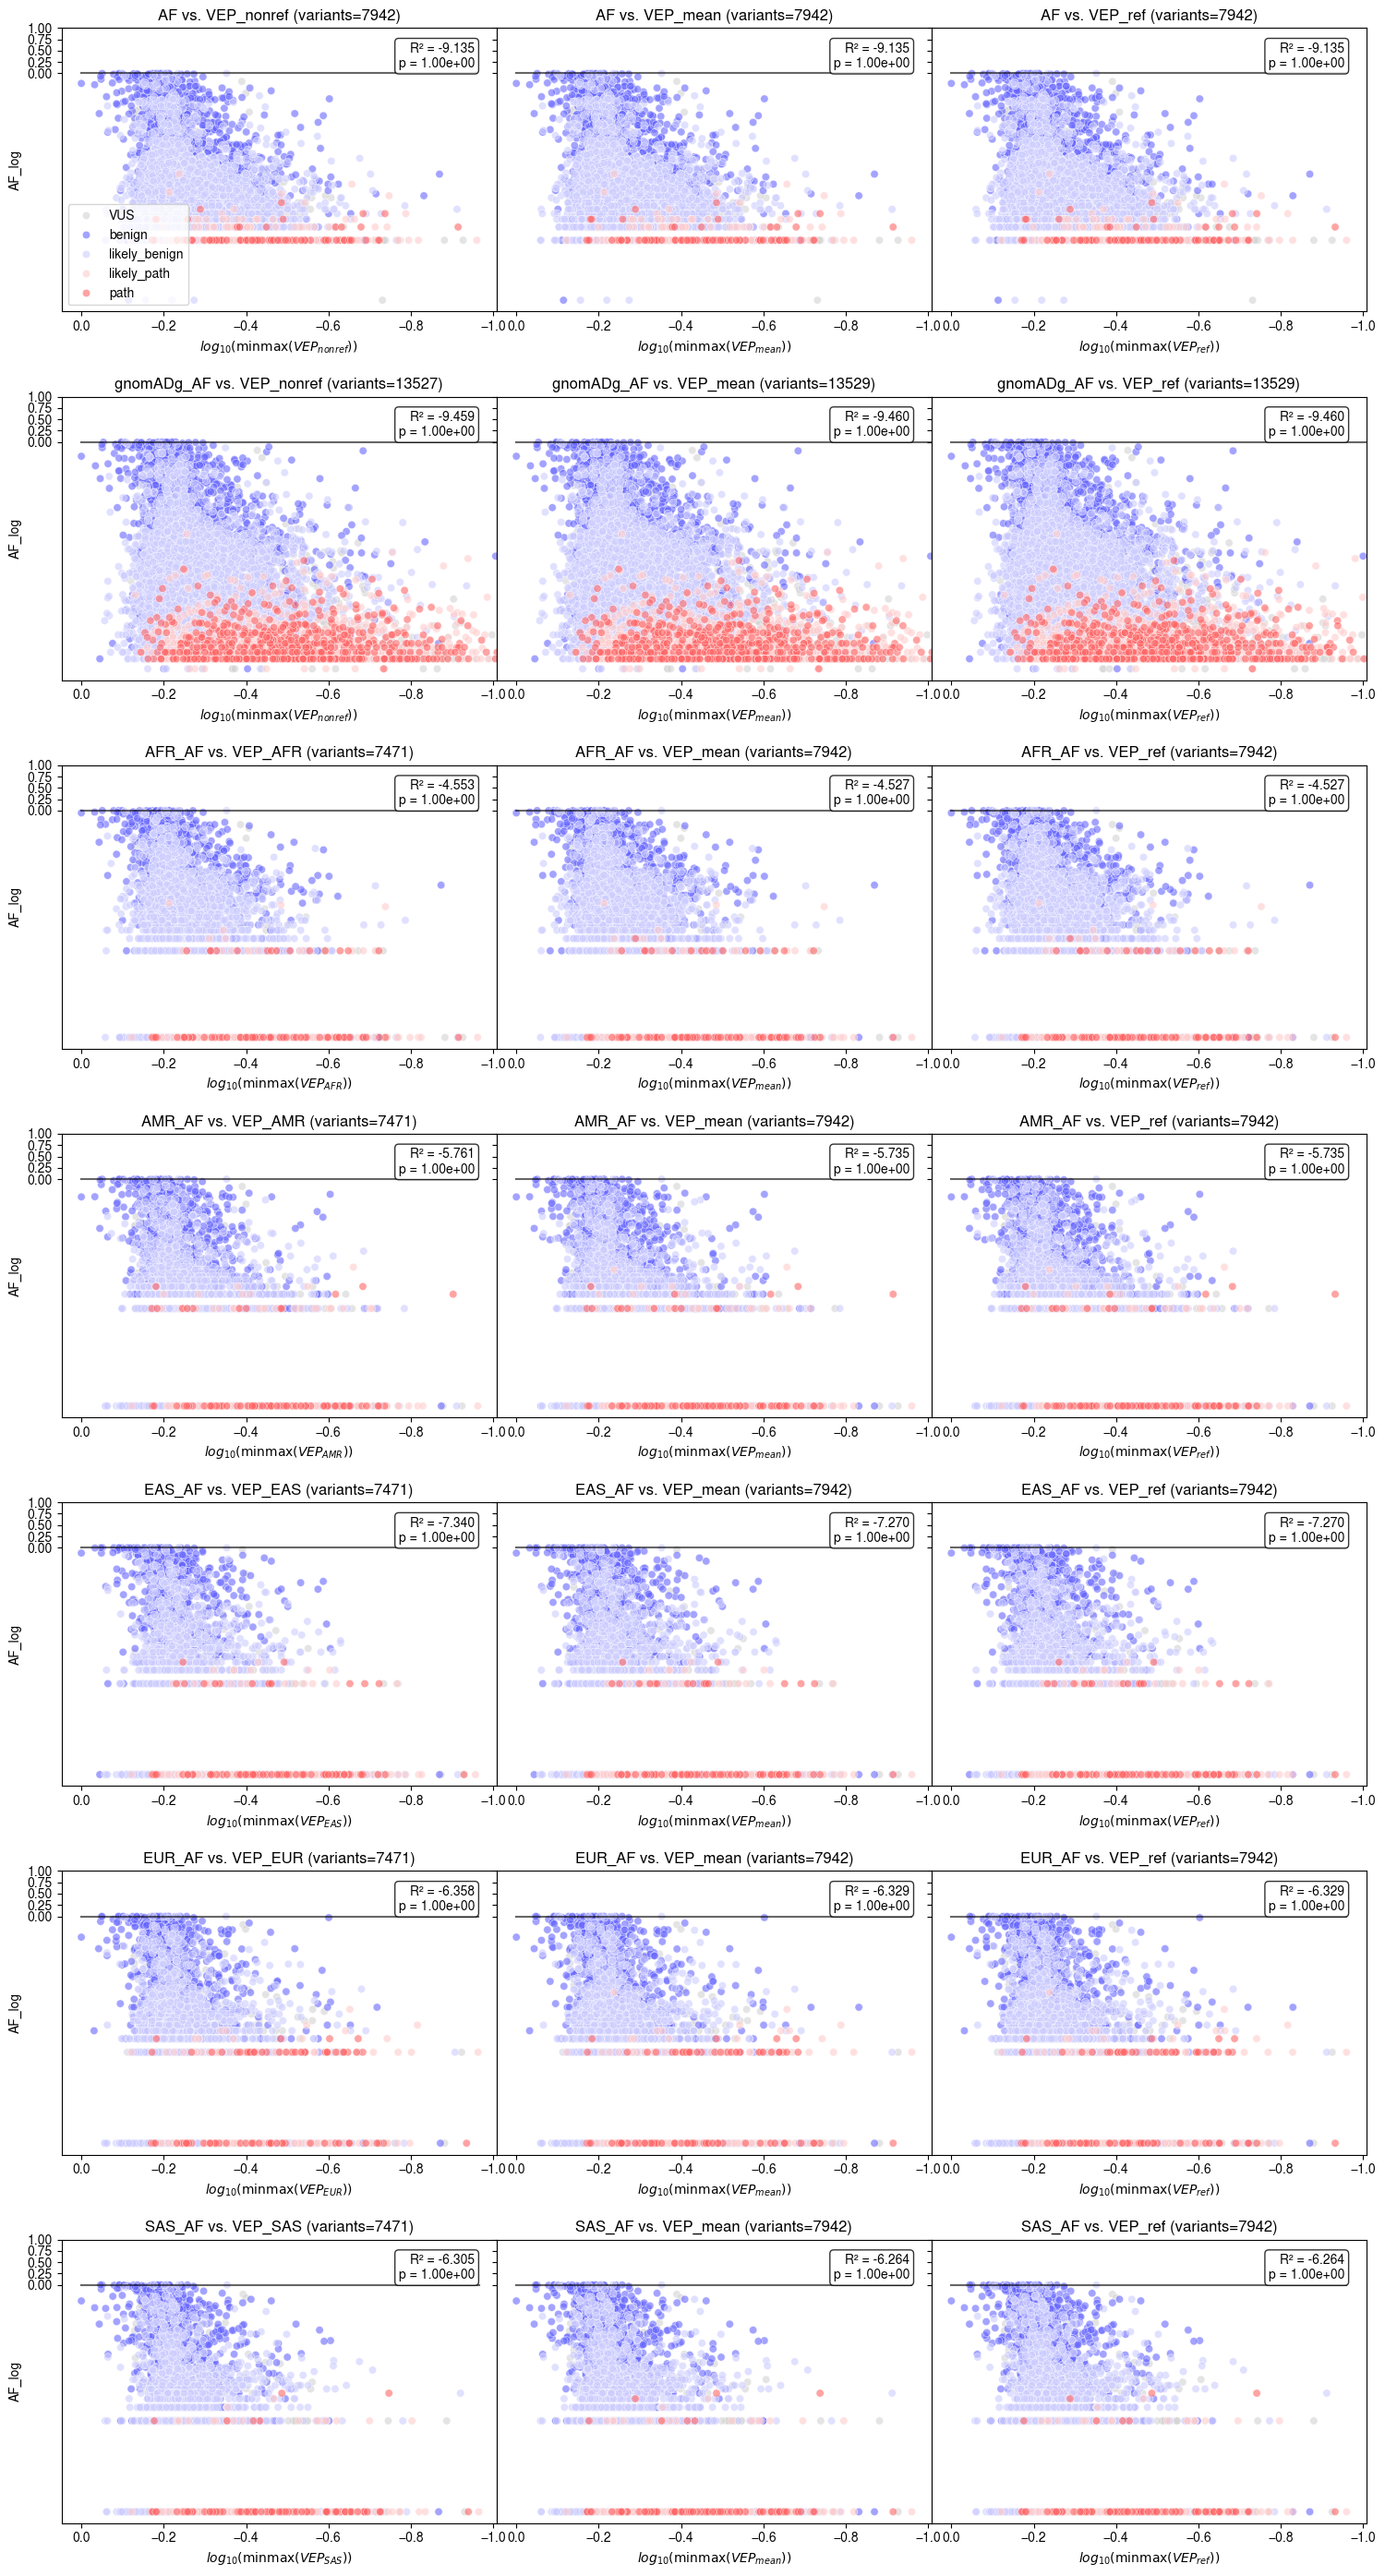

In [24]:
af_cols_extra=[
     '1000Gp3_AF',
 '1000Gp3_AFR_AF',
 '1000Gp3_AMR_AF',
 '1000Gp3_EAS_AF',
 '1000Gp3_EUR_AF',
 '1000Gp3_SAS_AF',
]
fig, axes = ev.plot_vep_vs_af_grid(
    vep_superpop_annot,
    af_cols=['AF', 'gnomADg_AF', 'AFR_AF', 'AMR_AF', 'EAS_AF', 'EUR_AF', 'SAS_AF'],
     logx=True,   # Log-transform VEP
    logy=True,   # Log-transform AF
    invert_xaxis=True,
    minmax_scale_vep=True,
    # fit_model="hyperbolic",
    sharex=True,
    hue="CLNSIG_simple",
    #  drop_vep_zeros=True,
    epsilon=1e-5,
    wspace=0,
    height=4,
    aspect=1.25,
    ylim=(0, 1)
)
utils.rasterize_figure(fig).savefig("manuscript/fig/vep_vs_af_grid.pdf", **utils.FIG_SAVE_KWARGS)

84
AF_coalesced


/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


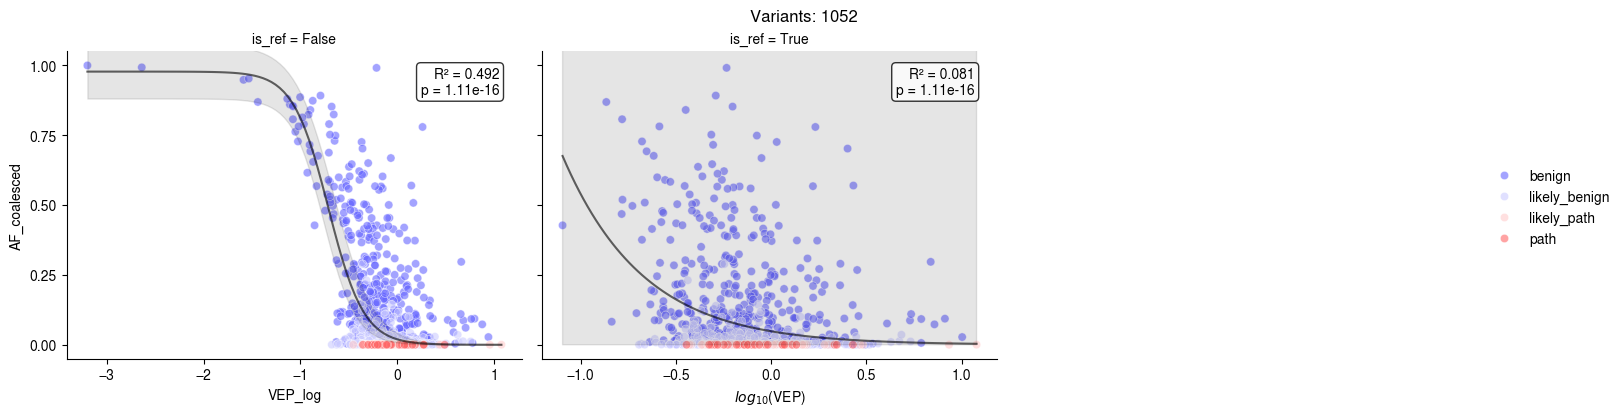

AF


/home/schilder/projects/VEP_DNA/src/vep_analysis.py:606: RuntimeWarning: overflow encountered in exp
  return L / (1 + np.exp(-k * (x - x0)))


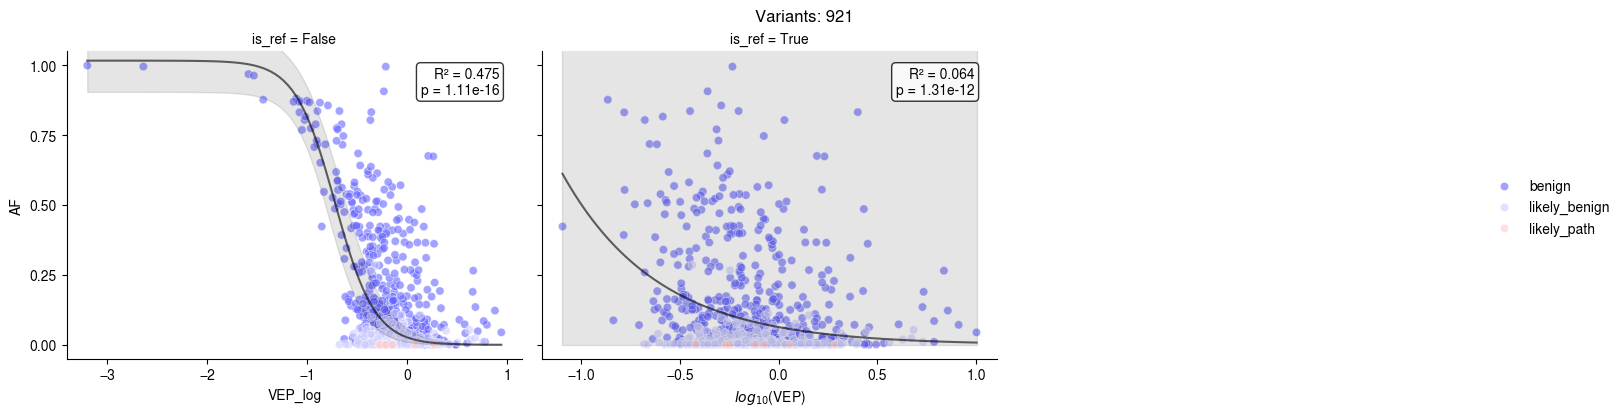

AFR_AF


/home/schilder/projects/VEP_DNA/src/vep_analysis.py:606: RuntimeWarning: overflow encountered in exp
  return L / (1 + np.exp(-k * (x - x0)))


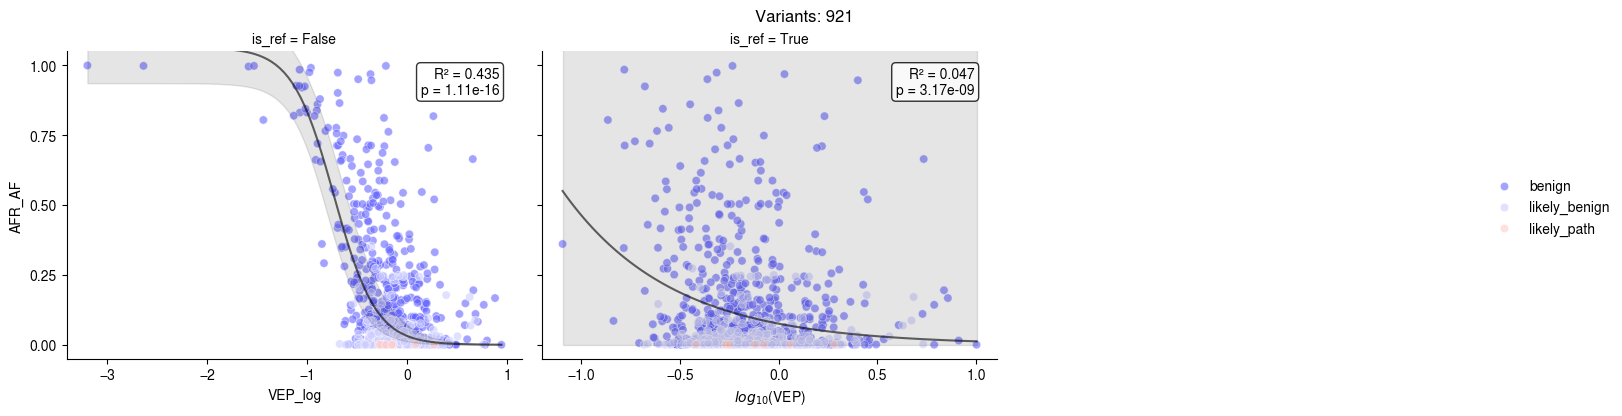

AMR_AF


/home/schilder/projects/VEP_DNA/src/vep_analysis.py:606: RuntimeWarning: overflow encountered in exp
  return L / (1 + np.exp(-k * (x - x0)))


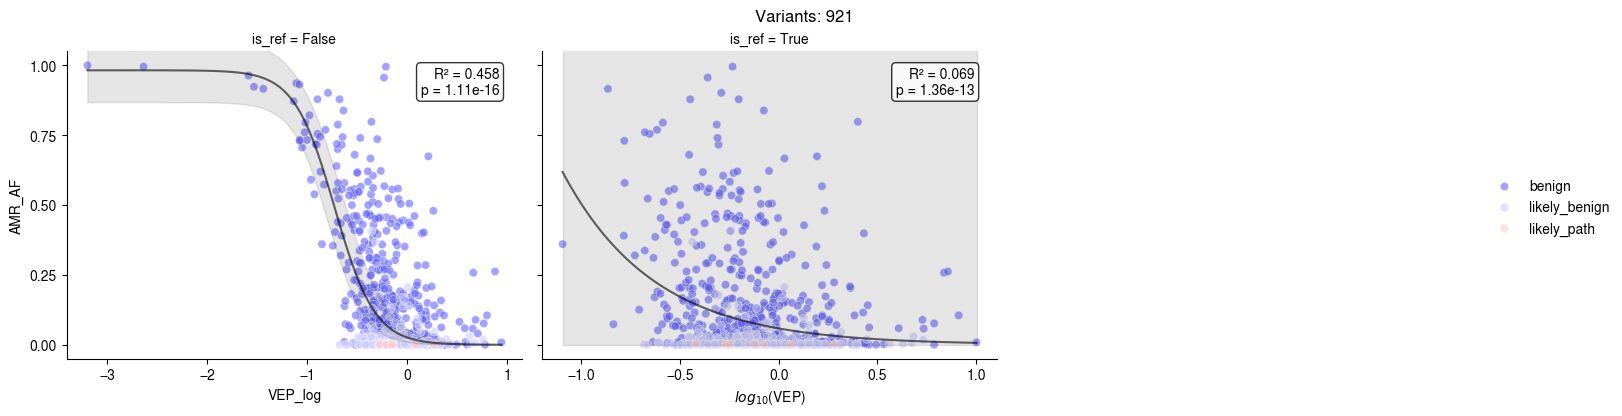

EAS_AF


/home/schilder/projects/VEP_DNA/src/vep_analysis.py:606: RuntimeWarning: overflow encountered in exp
  return L / (1 + np.exp(-k * (x - x0)))


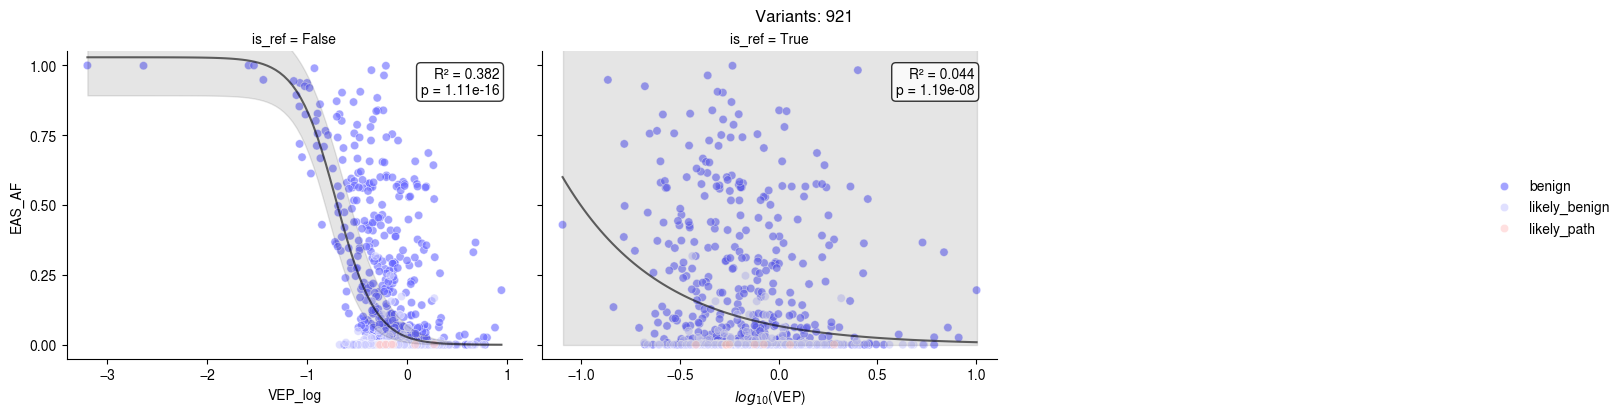

EUR_AF


/home/schilder/projects/VEP_DNA/src/vep_analysis.py:606: RuntimeWarning: overflow encountered in exp
  return L / (1 + np.exp(-k * (x - x0)))


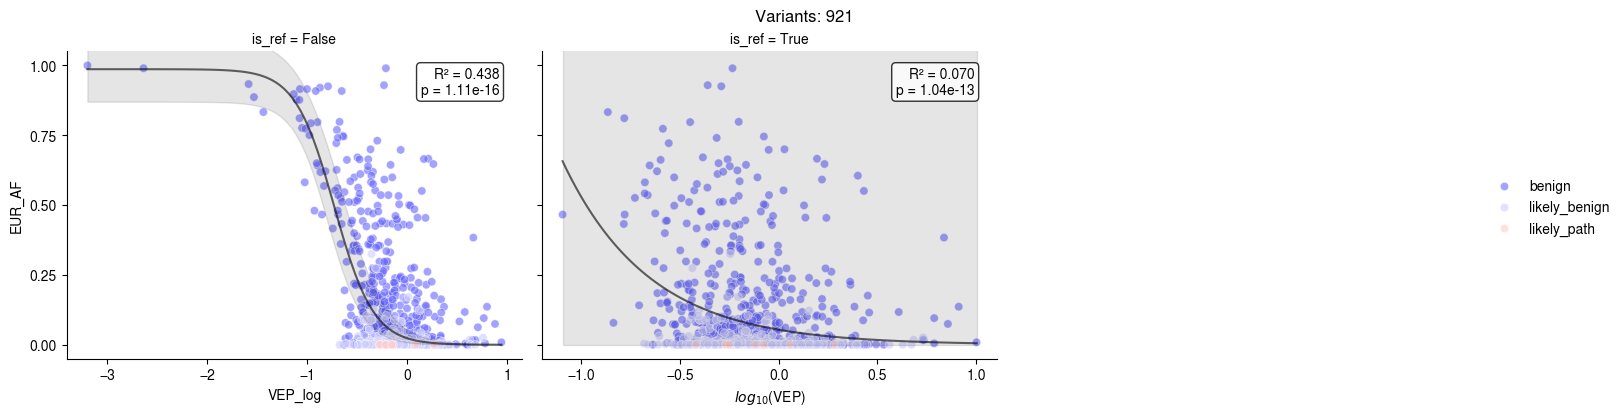

SAS_AF


/home/schilder/projects/VEP_DNA/src/vep_analysis.py:606: RuntimeWarning: overflow encountered in exp
  return L / (1 + np.exp(-k * (x - x0)))


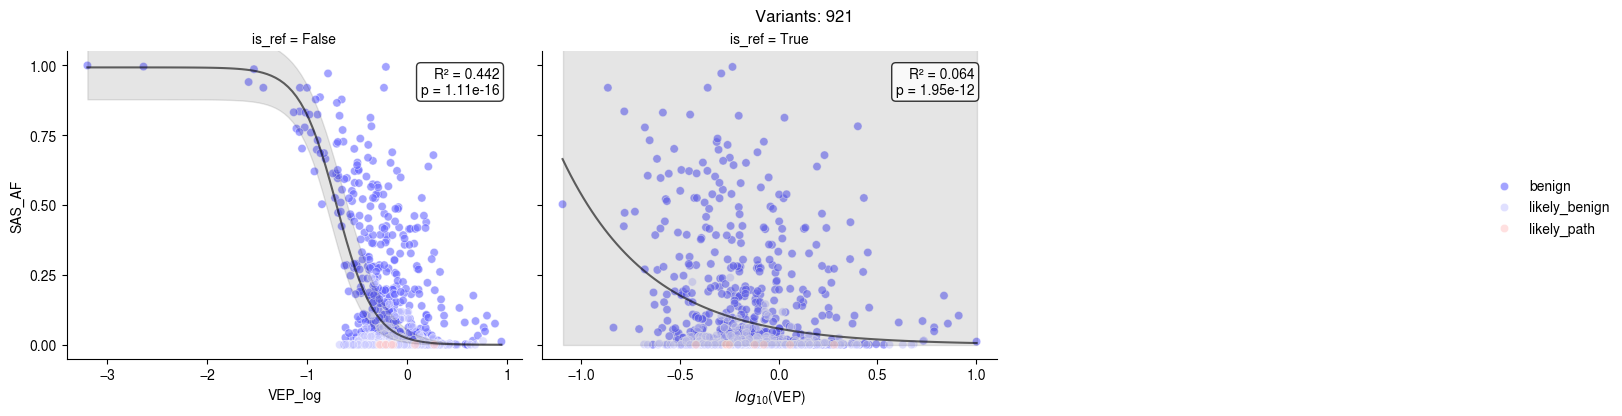

In [ ]:
import src.vep_analysis as va

# af_cols = [x for x in vep_annot.columns if x.endswith("AF")]
af_cols = [
 'AFR_AF',
 'AMR_AF',
 'EAS_AF',
 'EUR_AF',
 'SAS_AF'
 ]

print(len(af_cols))
vep_annot["VEP_log"] = np.log10(vep_annot["VEP"])
vep_annot["AF_coalesced"] = vep_annot[af_cols].mean(axis=1)

for i, af_col in enumerate(["AF_coalesced"]+af_cols):
    print(af_col)
    va.plot_vep_vs_af(vep_annot.loc[vep_annot["VEP"]!=0],
                    vep_col="VEP",
                    af_col=af_col,  # Use the current af_col instead of hardcoding AF_TGP
                    # fit_line=False,
                    # show_ci=False,
                    logx=True,
                    logy=False,
                    sharex=False,
                    # sharey=False,
                    col="is_ref", 
                    hue="CLNSIG_simple", 
                    height=4,
                    aspect=1.25,
                    ylim=(0, 1))  # Plot on the corresponding subplot axis 

    if i >5:
        break